In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv(r'C:\Users\user\Downloads\Dataset for Data Analyticsp1.csv')
df.shape


(1200, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   str    
 1   Date             1200 non-null   str    
 2   CustomerID       1200 non-null   str    
 3   Product          1200 non-null   str    
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   str    
 7   PaymentMethod    1200 non-null   str    
 8   OrderStatus      1200 non-null   str    
 9   TrackingNumber   1200 non-null   str    
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    str    
 12  ReferralSource   1200 non-null   str    
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 131.4 KB


In [6]:
print("Missing values:")
print(df.isnull().sum())


Missing values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [7]:
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate OrderIDs:", df['OrderID'].duplicated().sum())

Duplicate rows: 0
Duplicate OrderIDs: 0


In [8]:
print("Qty<=0:", (df['Quantity']<=0).sum())
print("UnitPrice<=0:", (df['UnitPrice']<=0).sum())
calc = df['Quantity']*df['UnitPrice']
mismatch = df[abs(calc - df['TotalPrice'])>1]
print("TotalPrice mismatches:", len(mismatch))


Qty<=0: 0
UnitPrice<=0: 0
TotalPrice mismatches: 0


In [9]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


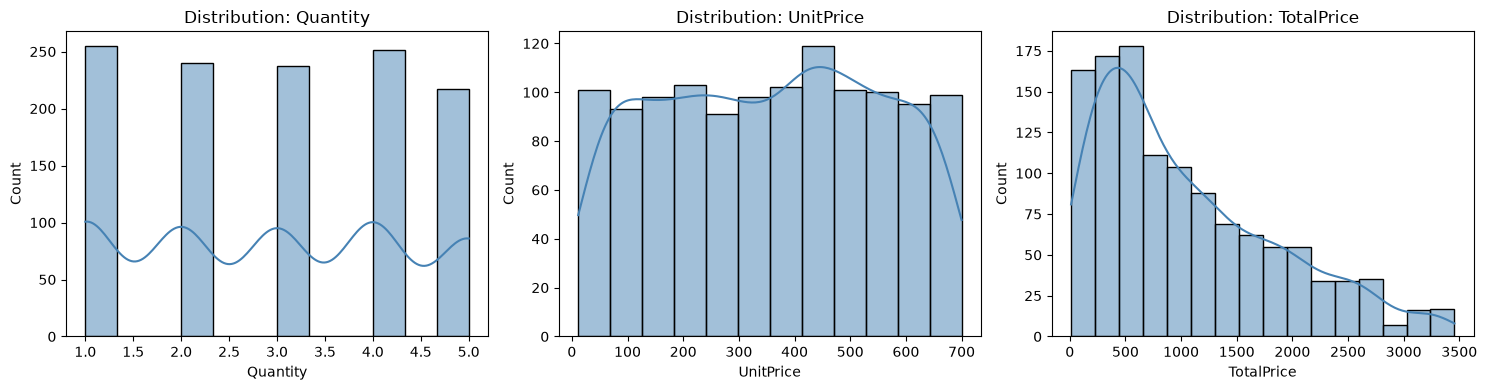

In [13]:
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['Quantity','UnitPrice','TotalPrice']):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution: {col}')
plt.tight_layout()
plt.show()


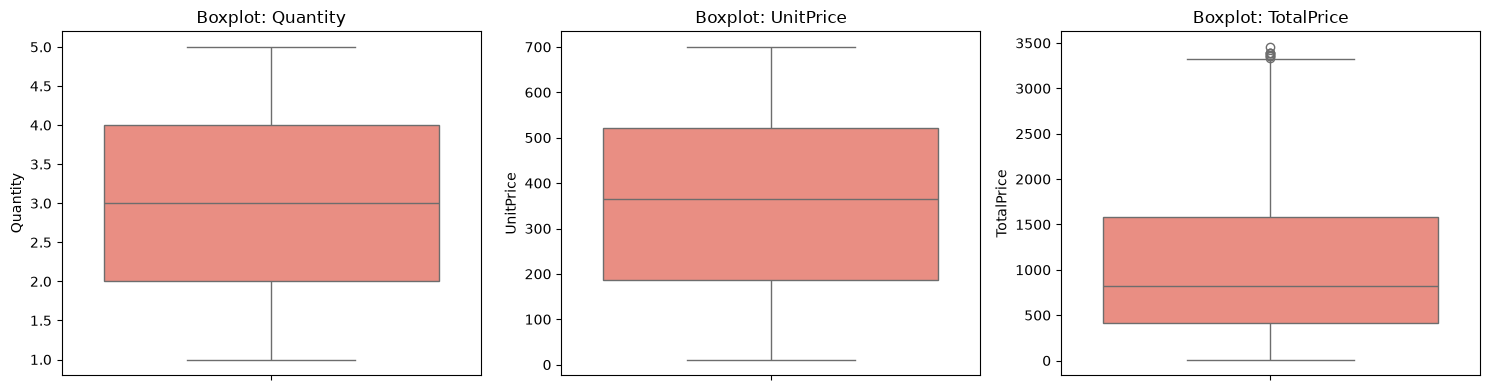

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['Quantity','UnitPrice','TotalPrice']):
    sns.boxplot(y=df[col], ax=ax, color='salmon')
    ax.set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

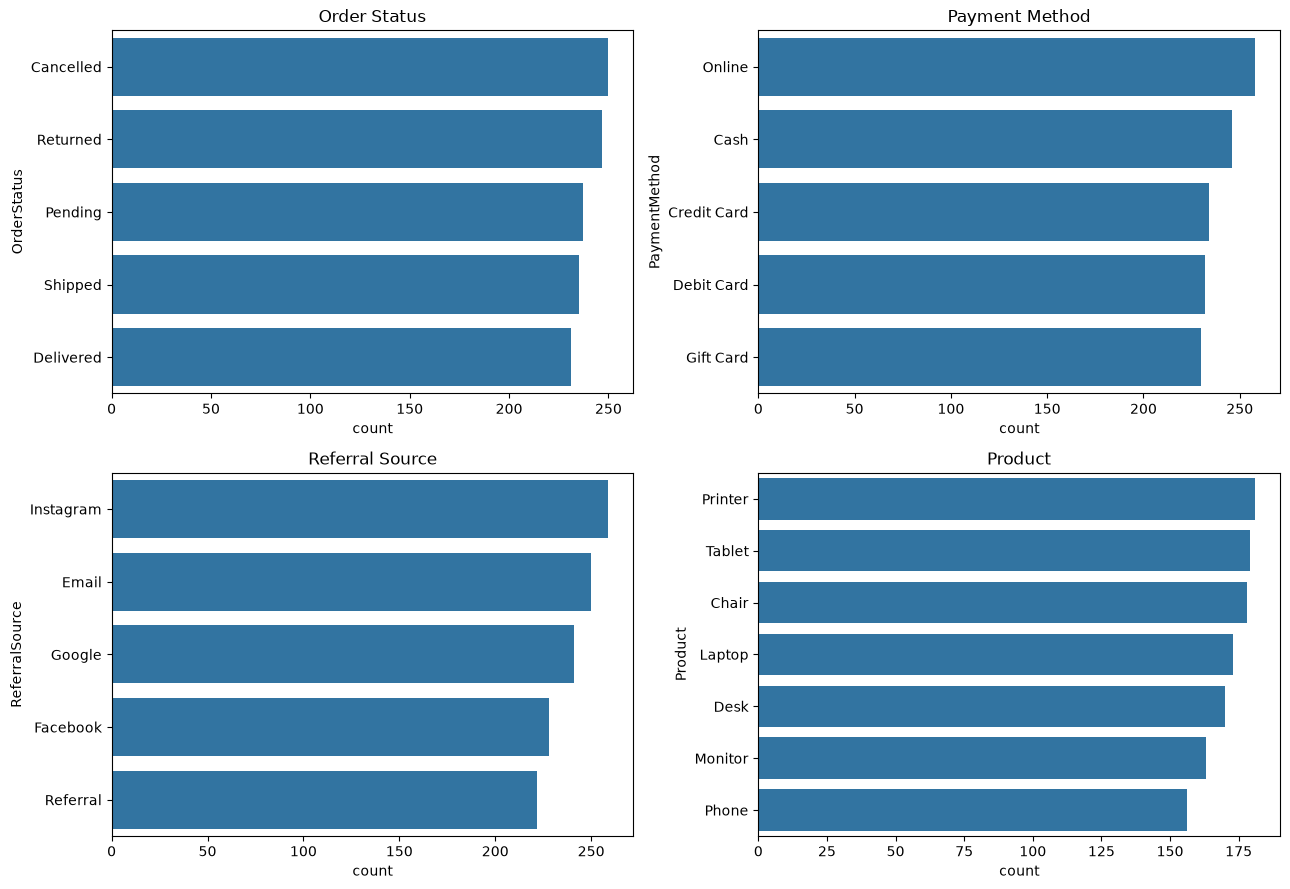

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13,9))
sns.countplot(data=df, y='OrderStatus', order=df['OrderStatus'].value_counts().index, ax=axes[0,0])
axes[0,0].set_title('Order Status')
sns.countplot(data=df, y='PaymentMethod', order=df['PaymentMethod'].value_counts().index, ax=axes[0,1])
axes[0,1].set_title('Payment Method')
sns.countplot(data=df, y='ReferralSource', order=df['ReferralSource'].value_counts().index, ax=axes[1,0])
axes[1,0].set_title('Referral Source')
sns.countplot(data=df, y='Product', order=df['Product'].value_counts().index, ax=axes[1,1])
axes[1,1].set_title('Product')
plt.tight_layout()
plt.show()

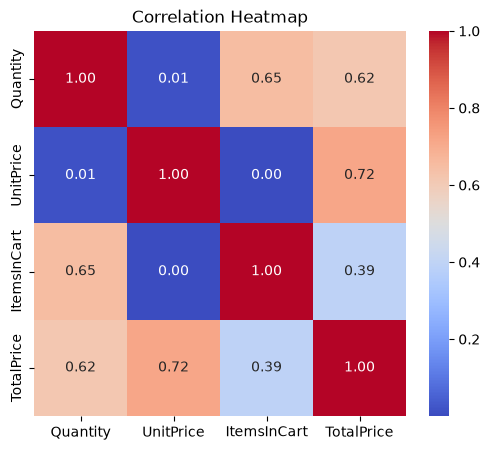

In [17]:
corr = df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

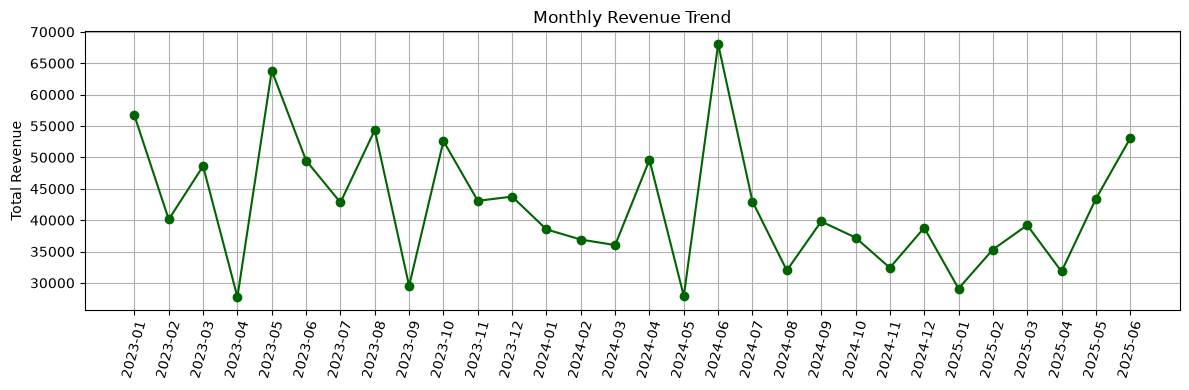

In [25]:
df['Month'] = df['Date'].dt.to_period('M').astype(str)
monthly = df.groupby('Month')['TotalPrice'].sum().reset_index()
plt.figure(figsize=(12,4))
plt.grid("True")
plt.plot(monthly['Month'], monthly['TotalPrice'], marker='o', color='darkgreen')
plt.xticks(rotation=75)
plt.title('Monthly Revenue Trend')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()


In [21]:
print(df['Date'].dtype) 

str


In [22]:
df['Date'] = pd.to_datetime(df['Date'])

In [24]:
print(df['Date'].dtype)  

datetime64[us]


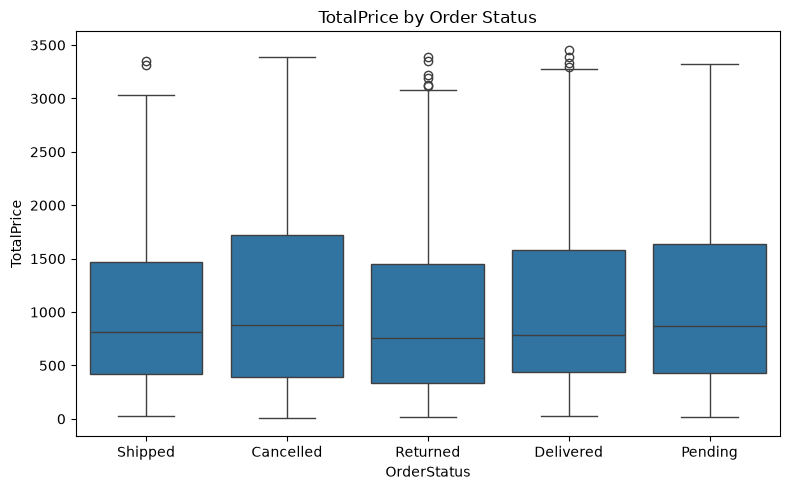

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='OrderStatus', y='TotalPrice')
plt.title('TotalPrice by Order Status')
plt.tight_layout()
plt.show()